In [ ]:
###########################################################################################################################################################

In [3]:
#################################Demo 2.3 Python Demo: Build Input Layer###########################################################################################################################################################

In [ ]:
# No internet/data downloads; everything is synthetic. Uses only common libs (torch, numpy, matplotlib).

In [2]:
#1-Batch & feature shapes, dtypes, and scaling

#2-Effect of scaling on the first projection (what many folks call the “input layer”)

#3-Categorical inputs: one‑hot vs embeddings (as an input layer)

#4-Images at input: HWC→CHW, normalization, flattening vs “ready for conv”

#5-Variable‑length sequences: padding + masks (input prep)

#6-Multi‑input merge: stitching different input types into one feature vector


DEMO 1: The Input Layer — shapes, scaling, encoding, padding, and merging.
We'll walk through 6 bite-sized sections. Keep your eye on printed SHAPES!

[1] Tabular input: batch & feature dimensions + scaling
Raw X shape: (512, 3) (batch, features) => (512, 3)
First 3 rows of X_raw:
 [[59.934284    0.47610518  0.1107271 ]
 [47.234715    0.40924364  0.43840355]
 [62.95377     0.44232288 -0.5430905 ]]


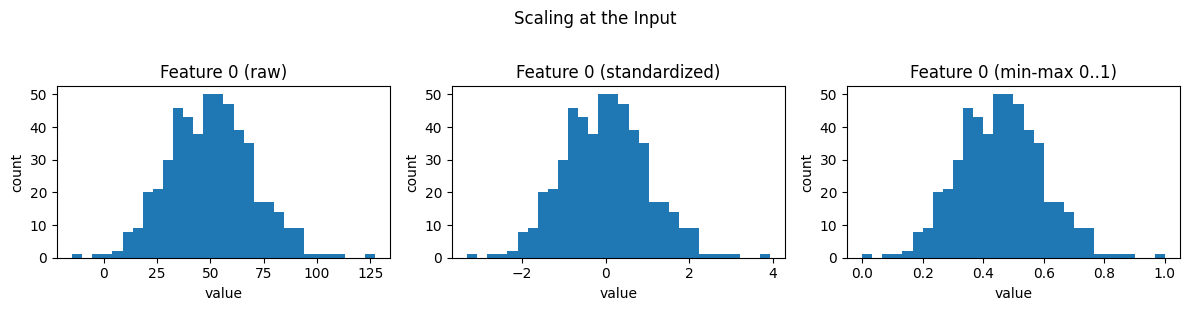

Standardization stats — mu: [ 5.0088371e+01  5.0543207e-01 -9.0936490e-05] sigma: [19.561255    0.09774688  0.5788968 ]
MinMax stats — xmin: [-14.825347     0.23031133  -0.99012005] xmax: [127.05463      0.7632382    0.99882746]
Imputed X shape: (512, 3) column means used: [5.0131424e+01 5.0646812e-01 3.9792839e-03]

[2] Effect of input scaling on the first projection (a.k.a. input layer)


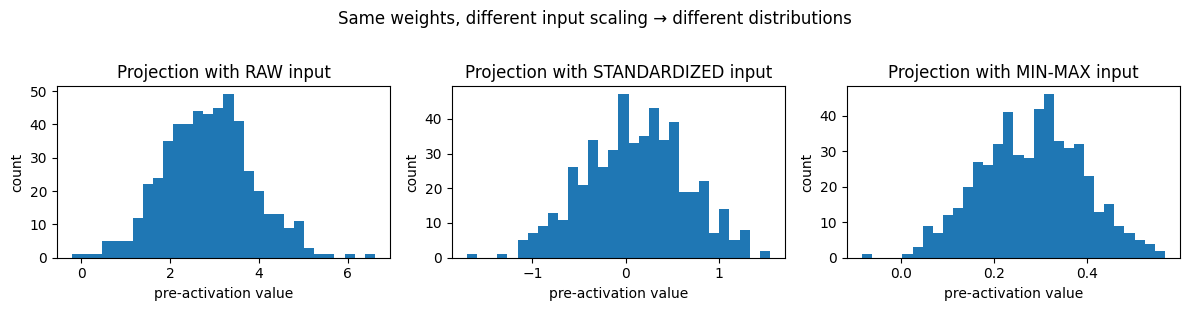

Notice how input scaling changes the distribution the next layer sees.

[3] Categorical inputs: one-hot vs embedding
One-hot shape: (512, 3) (batch, num_categories) => (512, 3)


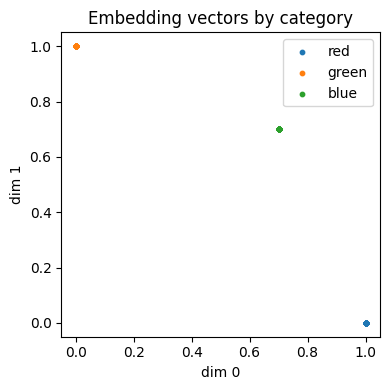

Embedding weight matrix (rows=categories, cols=embed dims):
[[1.  0. ]
 [0.  1. ]
 [0.7 0.7]]
Takeaway: One-hot produces sparse inputs; embeddings produce dense, low-dim inputs.

[4] Image inputs: layout, normalization, flattening


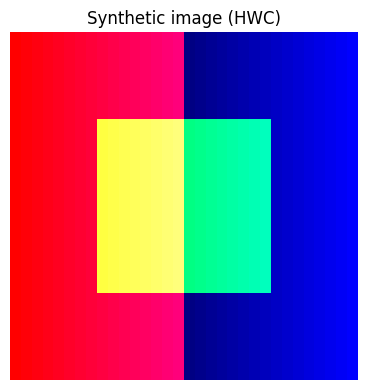

HWC shape: (32, 32, 3) → CHW shape: (3, 32, 32)
Per-channel normalized CHW: mean≈ [0.0000000e+00 2.9802322e-08 8.1956387e-08] std≈ [1. 1. 1.]
Flattened for Dense: (3072,)   /  Conv-ready: (1, 3, 32, 32)


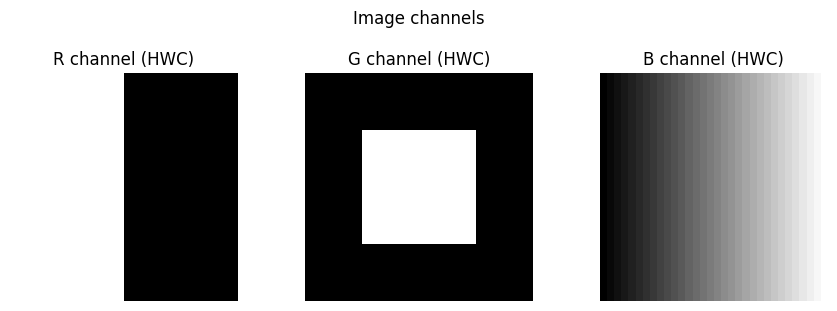


[5] Variable-length sequences: padding + masks (text/time-series)
Padded shape: (5, 7) (batch, time)
Mask shape: (5, 7) (1 for real token, 0 for pad)


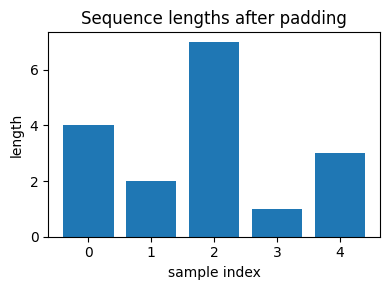

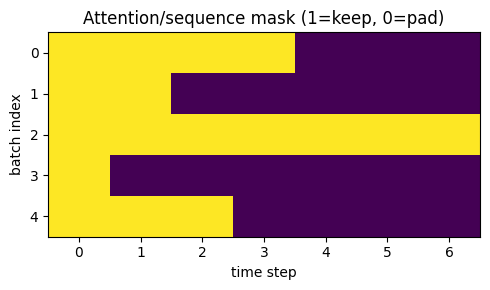

Embedded sequence shape: (5, 7, 4) -> (batch, time, emb_dim)

[6] Multi-input stitching at the input stage (no hidden layers yet)
Shapes — numeric: (5, 2) categorical-emb: (5, 3) text-pooled: (5, 6)
Merged INPUT vector shape: (5, 11) => (batch, features)


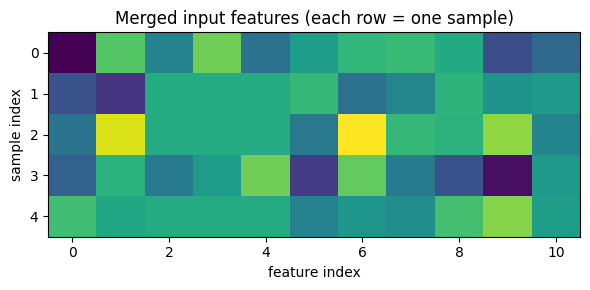


Demo 1 complete ✅ — everything you saw lives *before* any hidden layers:
• shaping inputs (batch, features/channels, time)
• scaling/normalizing, imputing
• encoding categorical features (one-hot vs embeddings)
• padding & masks for sequences
• merging multi-input data into a single input vector


In [1]:
# ===============================
# Week 1 — Demo 1: The Input Layer
# Run cell-by-cell if you're in a notebook, or as a script.
# Requires: torch, numpy, matplotlib
# ===============================

import os, math, random
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

# ---------- Utilities ----------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed(42)

def standardize(X):
    """Return standardized X and (mu, sigma)."""
    mu = X.mean(axis=0, keepdims=True)
    sigma = X.std(axis=0, keepdims=True) + 1e-8
    Z = (X - mu) / sigma
    return Z.astype(np.float32), mu.astype(np.float32), sigma.astype(np.float32)

def minmax_scale_01(X):
    xmin = X.min(axis=0, keepdims=True)
    xmax = X.max(axis=0, keepdims=True)
    rng = (xmax - xmin) + 1e-8
    Z = (X - xmin) / rng
    return Z.astype(np.float32), xmin.astype(np.float32), xmax.astype(np.float32)

def impute_nan_mean(X):
    """Mean-impute NaNs column-wise."""
    X = X.copy().astype(np.float32)
    col_means = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_means, inds[1])
    return X, col_means.astype(np.float32)

def one_hot(indices, num_classes):
    indices = np.asarray(indices, dtype=np.int64)
    eye = np.eye(num_classes, dtype=np.float32)
    return eye[indices]  # shape (N, C)

def pad_sequences(seq_list, pad_value=0):
    """
    seq_list: list of lists (token ids).
    Returns: padded (B, T), mask (B, T)
    """
    max_len = max(len(s) for s in seq_list)
    B = len(seq_list)
    padded = np.full((B, max_len), pad_value, dtype=np.int64)
    mask = np.zeros((B, max_len), dtype=np.float32)
    for i, s in enumerate(seq_list):
        L = len(s)
        padded[i, :L] = np.array(s, dtype=np.int64)
        mask[i, :L] = 1.0
    return padded, mask

def show(title=None):
    if title: plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

print("DEMO 1: The Input Layer — shapes, scaling, encoding, padding, and merging.")
print("We'll walk through 6 bite-sized sections. Keep your eye on printed SHAPES!")

# --------------------------------------------------------
# 1) Tabular numeric input: batch & feature shapes + scaling
# --------------------------------------------------------
print("\n[1] Tabular input: batch & feature dimensions + scaling")

# Synthetic 3-feature dataset (B x F)
B = 512
F = 3
X_raw = np.c_[np.random.normal(50, 20, size=B),     # Feature 0 ~ big scale
              np.random.normal(0.5, 0.1, size=B),   # Feature 1 ~ small scale
              np.random.uniform(-1, 1, size=B)]     # Feature 2 ~ uniform
X_raw = X_raw.astype(np.float32)

print("Raw X shape:", X_raw.shape, "(batch, features) =>", (B, F))
print("First 3 rows of X_raw:\n", X_raw[:3])

# Plot distributions before/after standardization
X_std, mu, sigma = standardize(X_raw)
X_minmax, xmin, xmax = minmax_scale_01(X_raw)

fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].hist(X_raw[:,0], bins=30)
axs[0].set_title("Feature 0 (raw)")
axs[1].hist(X_std[:,0], bins=30)
axs[1].set_title("Feature 0 (standardized)")
axs[2].hist(X_minmax[:,0], bins=30)
axs[2].set_title("Feature 0 (min-max 0..1)")
for ax in axs: ax.set_xlabel("value"); ax.set_ylabel("count")
show("Scaling at the Input")

print("Standardization stats — mu:", mu.ravel(), "sigma:", sigma.ravel())
print("MinMax stats — xmin:", xmin.ravel(), "xmax:", xmax.ravel())

# Demonstrate imputation (pretend some values are missing at input)
X_with_nan = X_raw.copy()
nan_mask = np.random.rand(*X_with_nan.shape) < 0.02  # 2% NaNs
X_with_nan[nan_mask] = np.nan
X_imputed, col_means = impute_nan_mean(X_with_nan)
print("Imputed X shape:", X_imputed.shape, "column means used:", col_means)

# --------------------------------------------------------
# 2) Why scaling matters: effect on the FIRST linear projection
# --------------------------------------------------------
print("\n[2] Effect of input scaling on the first projection (a.k.a. input layer)")

# Freeze a linear "input layer" so we can compare apples-to-apples
in_features = F
out_features = 1
layer = nn.Linear(in_features, out_features, bias=True)
with torch.no_grad():
    layer.weight[:] = torch.tensor([[0.05, 0.5, -0.2]])  # fixed weights
    layer.bias[:] = torch.tensor([0.1])

Y_raw = layer(torch.from_numpy(X_raw))        # no scaling
Y_std = layer(torch.from_numpy(X_std))        # standardized
Y_minmax = layer(torch.from_numpy(X_minmax))  # min-max

# Plot the output distributions
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].hist(Y_raw.detach().numpy().ravel(), bins=30)
axs[0].set_title("Projection with RAW input")
axs[1].hist(Y_std.detach().numpy().ravel(), bins=30)
axs[1].set_title("Projection with STANDARDIZED input")
axs[2].hist(Y_minmax.detach().numpy().ravel(), bins=30)
axs[2].set_title("Projection with MIN-MAX input")
for ax in axs: ax.set_xlabel("pre-activation value"); ax.set_ylabel("count")
show("Same weights, different input scaling → different distributions")

print("Notice how input scaling changes the distribution the next layer sees.")

# --------------------------------------------------------
# 3) Categorical inputs: one-hot vs embedding as INPUT layers
# --------------------------------------------------------
print("\n[3] Categorical inputs: one-hot vs embedding")

# Suppose we have a color feature with 3 categories
categories = ["red", "green", "blue"]
cat_to_id = {c:i for i,c in enumerate(categories)}

# Create a batch of category strings
cats = np.random.choice(categories, size=B)
cat_ids = np.array([cat_to_id[c] for c in cats], dtype=np.int64)

# One-hot encode
C = len(categories)
X_cat_oh = one_hot(cat_ids, num_classes=C)  # shape (B, C)
print("One-hot shape:", X_cat_oh.shape, "(batch, num_categories) =>", (B, C))

# Embedding as input layer (maps category id -> learned vector)
embed_dim = 2  # 2D so we can easily visualize
embed = nn.Embedding(num_embeddings=C, embedding_dim=embed_dim)
with torch.no_grad():
    # Fix weights for demo (so plots are stable)
    embed.weight[:] = torch.tensor([[1.0, 0.0],
                                    [0.0, 1.0],
                                    [0.7, 0.7]])

E = embed(torch.from_numpy(cat_ids))  # (B, embed_dim)
E_np = E.detach().numpy()

# Scatter plot of embedding space colored by category id
plt.figure(figsize=(4,4))
for i, name in enumerate(categories):
    pts = E_np[cat_ids==i]
    plt.scatter(pts[:,0], pts[:,1], label=name, s=10)
plt.legend()
plt.title("Embedding vectors by category")
plt.xlabel("dim 0"); plt.ylabel("dim 1")
show()

print("Embedding weight matrix (rows=categories, cols=embed dims):")
print(embed.weight.detach().numpy())

print("Takeaway: One-hot produces sparse inputs; embeddings produce dense, low-dim inputs.")

# --------------------------------------------------------
# 4) Image inputs: HWC → CHW, normalization, flatten vs conv-ready
# --------------------------------------------------------
print("\n[4] Image inputs: layout, normalization, flattening")

# Make a simple synthetic RGB image (HWC)
H, W, Cimg = 32, 32, 3
img = np.zeros((H, W, Cimg), dtype=np.float32)
img[:,:W//2,0] = 1.0   # left half red
img[H//4:3*H//4, W//4:3*W//4, 1] = 1.0  # green box center
img[:, :, 2] = np.linspace(0, 1, W)[None, :]  # blue gradient horizontally

plt.figure(figsize=(4,4))
plt.imshow(np.clip(img, 0, 1))
plt.title("Synthetic image (HWC)")
plt.axis('off')
show()

# Convert to CHW (channels-first) for many DL frameworks (e.g., PyTorch)
img_chw = np.transpose(img, (2, 0, 1))  # (C, H, W)
print("HWC shape:", img.shape, "→ CHW shape:", img_chw.shape)

# Normalize per-channel to zero-mean, unit-var (common input prep)
img_chw_norm = img_chw.copy()
for c in range(Cimg):
    m = img_chw[c].mean()
    s = img_chw[c].std() + 1e-8
    img_chw_norm[c] = (img_chw[c] - m) / s
print("Per-channel normalized CHW: mean≈", img_chw_norm.mean(axis=(1,2)),
      "std≈", img_chw_norm.std(axis=(1,2)))

# Two common “input shapes” depending on model family:
x_for_dense = img_chw.reshape(-1)      # flatten to vector (F,) if using MLP
x_for_conv  = img_chw[np.newaxis, ...] # add batch: (1, C, H, W) for ConvNets
print("Flattened for Dense:", x_for_dense.shape, "  /  Conv-ready:", x_for_conv.shape)

# Visualize channels
fig, axs = plt.subplots(1,3, figsize=(9,3))
for c, name in enumerate(["R","G","B"]):
    axs[c].imshow(img[:,:,c], cmap='gray')
    axs[c].set_title(f"{name} channel (HWC)")
    axs[c].axis('off')
show("Image channels")

# --------------------------------------------------------
# 5) Variable-length sequences: padding and masks at INPUT
# --------------------------------------------------------
print("\n[5] Variable-length sequences: padding + masks (text/time-series)")

# Toy tokenized text (IDs). Different lengths per sample.
seqs = [
    [5, 2, 9, 4],
    [3, 3],
    [7, 1, 1, 8, 2, 2, 2],
    [4],
    [6, 6, 6]
]
padded, mask = pad_sequences(seqs, pad_value=0)  # 0 will serve as PAD
print("Padded shape:", padded.shape, "(batch, time)")
print("Mask shape:", mask.shape, "(1 for real token, 0 for pad)")

# Visualize mask & lengths
lengths = mask.sum(axis=1)
plt.figure(figsize=(4,3))
plt.bar(np.arange(len(seqs)), lengths)
plt.title("Sequence lengths after padding")
plt.xlabel("sample index"); plt.ylabel("length")
show()

plt.figure(figsize=(5,3))
plt.imshow(mask, aspect='auto')
plt.title("Attention/sequence mask (1=keep, 0=pad)")
plt.xlabel("time step"); plt.ylabel("batch index")
show()

# Input Embedding for sequences
vocab_size = 10
emb_dim = 4
emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)  # padding_idx keeps PAD at zeros
E_seq = emb(torch.from_numpy(padded))  # (B, T, emb_dim)
print("Embedded sequence shape:", tuple(E_seq.shape), "-> (batch, time, emb_dim)")

# --------------------------------------------------------
# 6) Merging multiple input types into one vector (multi-input)
# --------------------------------------------------------
print("\n[6] Multi-input stitching at the input stage (no hidden layers yet)")

# Numeric (2 features), categorical (-> embedding), and text (mean-pooled embedding)
B2 = 5
X_num = np.random.randn(B2, 2).astype(np.float32)

# categorical ids in [0..C-1]
C2 = 4; cat_ids2 = np.random.randint(0, C2, size=(B2,), dtype=np.int64)
emb_cat = nn.Embedding(C2, 3)
with torch.no_grad():
    emb_cat.weight[:] = torch.tensor([[ 1.0, 0.0, 0.0],
                                      [ 0.0, 1.0,-0.2],
                                      [-0.1,0.3, 1.0],
                                      [ 0.5, 0.5, 0.5]])
X_cat_emb = emb_cat(torch.from_numpy(cat_ids2))  # (B2, 3)

# short text sequences
seqs2 = [[2,4,5],[1,1,1,3],[6],[7,8,2,2],[4,4]]
padded2, mask2 = pad_sequences(seqs2, pad_value=0)
emb2 = nn.Embedding(10, 6, padding_idx=0)
E_seq2 = emb2(torch.from_numpy(padded2))  # (B2, T, 6)
mask2_t = torch.from_numpy(mask2).unsqueeze(-1)    # (B2, T, 1)
# mean-pool over time using the mask
sum_pooled = (E_seq2 * mask2_t).sum(dim=1)         # (B2, 6)
len_vec = torch.from_numpy(mask2.sum(axis=1)).unsqueeze(-1) + 1e-8
X_text_pooled = sum_pooled / len_vec               # (B2, 6)

# Final stitched input vector (to feed next layers)
X_merged = torch.cat([
    torch.from_numpy(X_num),        # (B2, 2)
    X_cat_emb,                      # (B2, 3)
    X_text_pooled                   # (B2, 6)
], dim=1)
print("Shapes — numeric:", X_num.shape,
      "categorical-emb:", tuple(X_cat_emb.shape),
      "text-pooled:", tuple(X_text_pooled.shape))
print("Merged INPUT vector shape:", tuple(X_merged.shape), "=> (batch, features)")

plt.figure(figsize=(6,3))
plt.imshow(X_merged.detach().numpy(), aspect='auto')
plt.title("Merged input features (each row = one sample)")
plt.xlabel("feature index"); plt.ylabel("sample index")
show()

print("\nDemo 1 complete ✅ — everything you saw lives *before* any hidden layers:")
print("• shaping inputs (batch, features/channels, time)")
print("• scaling/normalizing, imputing")
print("• encoding categorical features (one-hot vs embeddings)")
print("• padding & masks for sequences")
print("• merging multi-input data into a single input vector")


In [4]:
# ================================
#Building an Input Layer
# ================================

# Import the required Keras modules
from keras.models import Sequential   # Sequential = simple linear stack of layers
from keras.layers import Dense        # Dense = fully connected layer

# Step 1: Define the number of input features (columns in your dataset)
# For example, if your dataset has 10 features, we set n_inputs = 10
n_inputs = 10

# Step 2: Initialize the Sequential model
# Sequential means we are going to add layers one after another
model = Sequential()

# Step 3: Add the input layer
# In Keras, the first Dense layer you add also serves as the input layer.
# - units=32 → number of neurons in this layer
# - activation='relu' → activation function used in this layer
# - input_shape=(n_inputs,) → tells Keras how many input features to expect
model.add(Dense(units=32, activation='relu', input_shape=(n_inputs,)))

# Step 4: Print the model summary
# This shows how the data flows from the input layer through the network
model.summary()


2025-08-22 09:00:21.359090: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-22 09:00:21.367710: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755853221.376685 2123373 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755853221.379441 2123373 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755853221.387391 2123373 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352 (1.38 KB)

 Trainable params: 352 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 10 neurons * 32 weights + 32 Biases = 352 parameter the network needs to find

In [7]:
###################################################################################################################################################################################################

In [8]:
################################# Demo 2.6 Python Demo: Build Hidden Layer###################################################################################################################

In [ ]:
#1-shows how data flows input → hidden layer → next layer

#2-visualizes 5 activation functions (curves + derivatives)

#3-trains small MLPs with each activation on a non‑linear 2‑class toy dataset

#4-plots decision boundaries, loss curves, and hidden‑space transformations

#Activations covered: ReLU, Sigmoid, Tanh, LeakyReLU(0.1), ELU

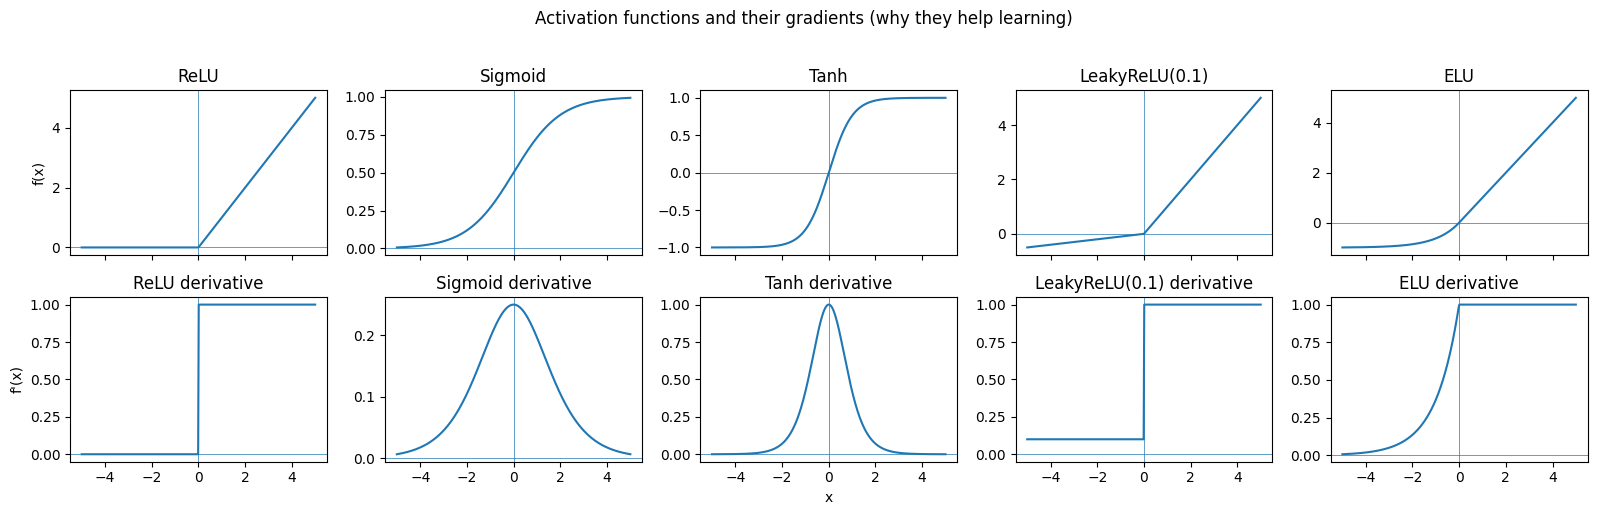


Why use activations?
• Without a nonlinearity, stacking Dense layers collapses to a single linear map → can't model curved boundaries.
• Activations add nonlinearity, letting hidden layers bend/warp space to separate classes.
• Gradients (bottom row) show where learning is fast/slow:
  - Sigmoid/Tanh can saturate (near 0 or ±1), shrinking gradients.
  - ReLU is simple and fast but 'dies' for x<0 (gradient 0).
  - LeakyReLU keeps small gradient when x<0.
  - ELU smooths negatives and pushes mean activations toward 0, which can speed learning.

Data shape: (600, 2) Labels shape: (600,)


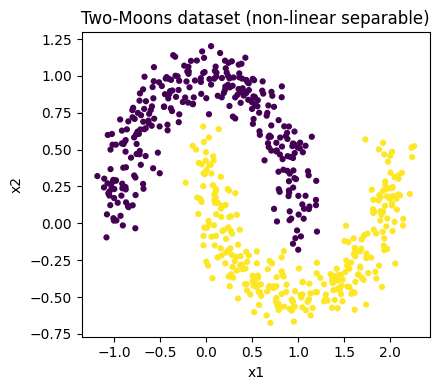


Training with activation: (Linear baseline)

Training with activation: ReLU

Training with activation: Sigmoid

Training with activation: Tanh

Training with activation: LeakyReLU(0.1)

Training with activation: ELU


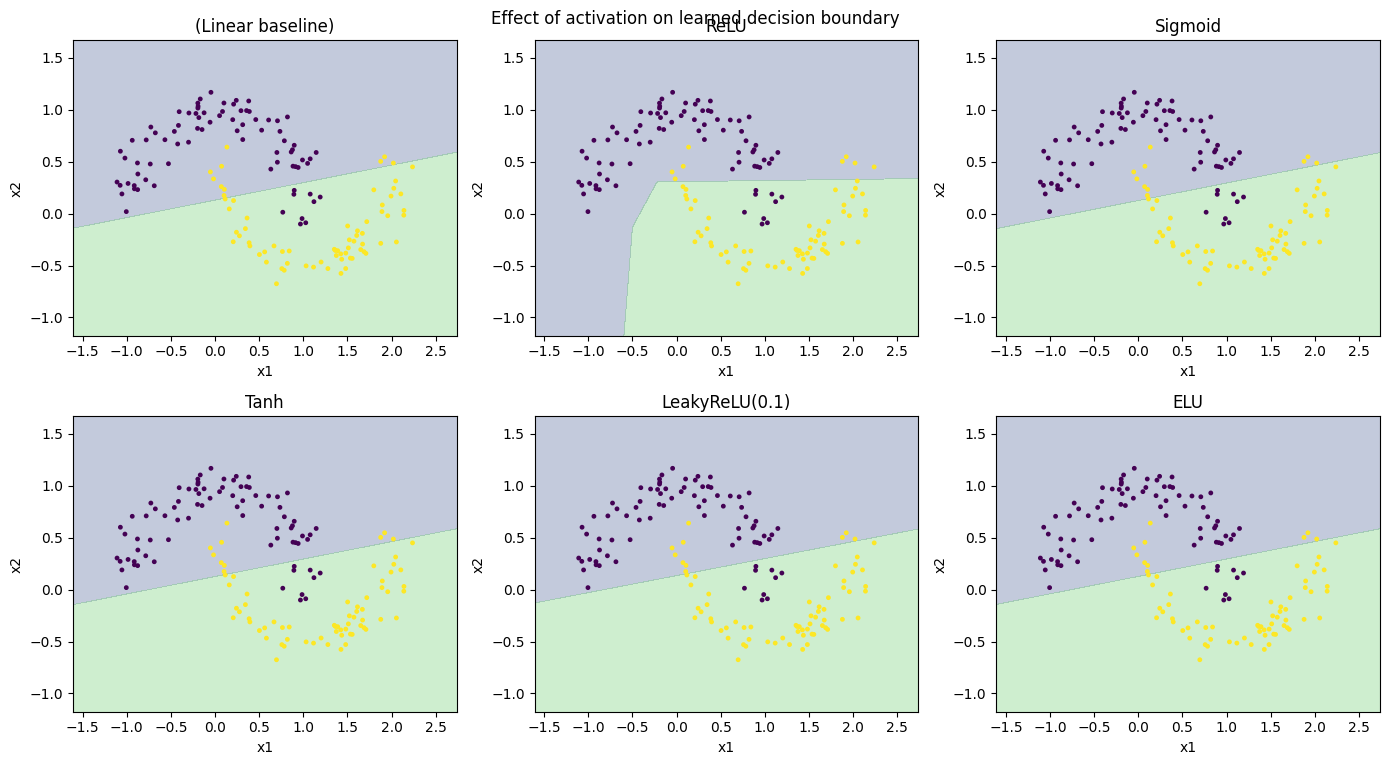

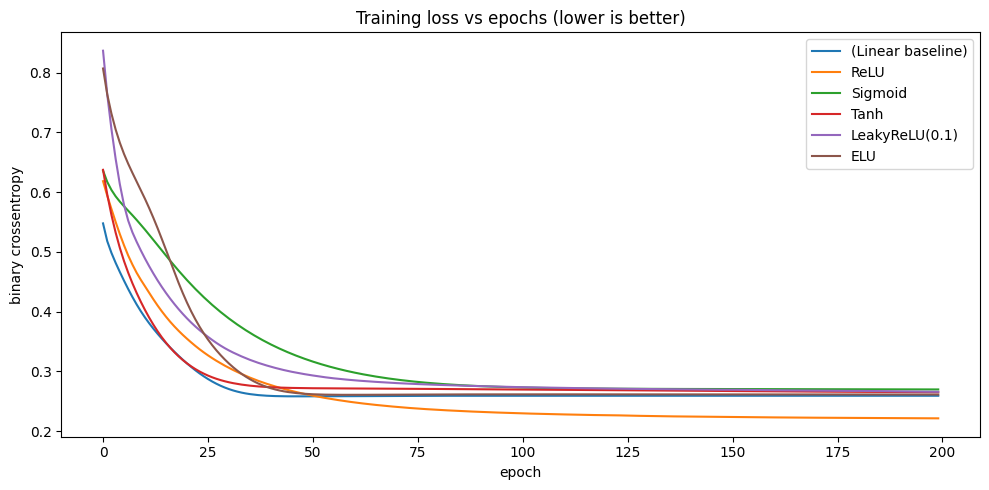

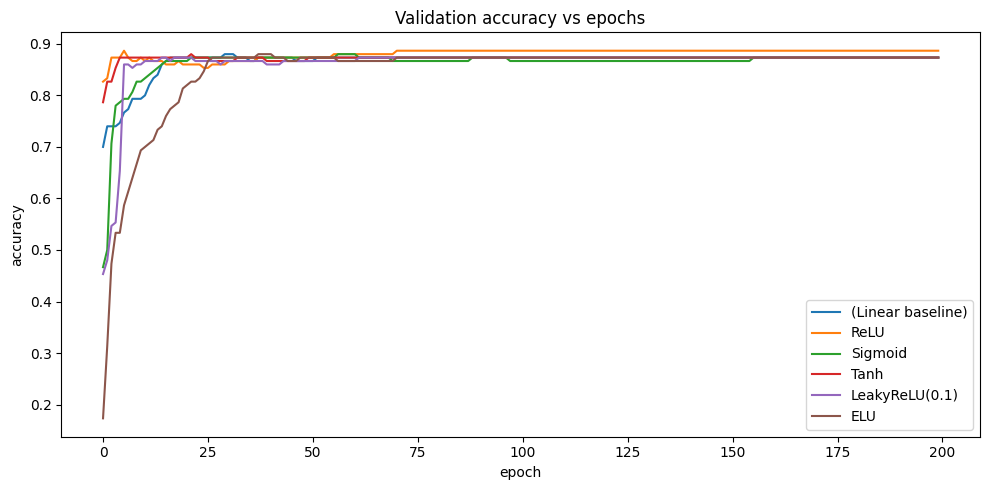

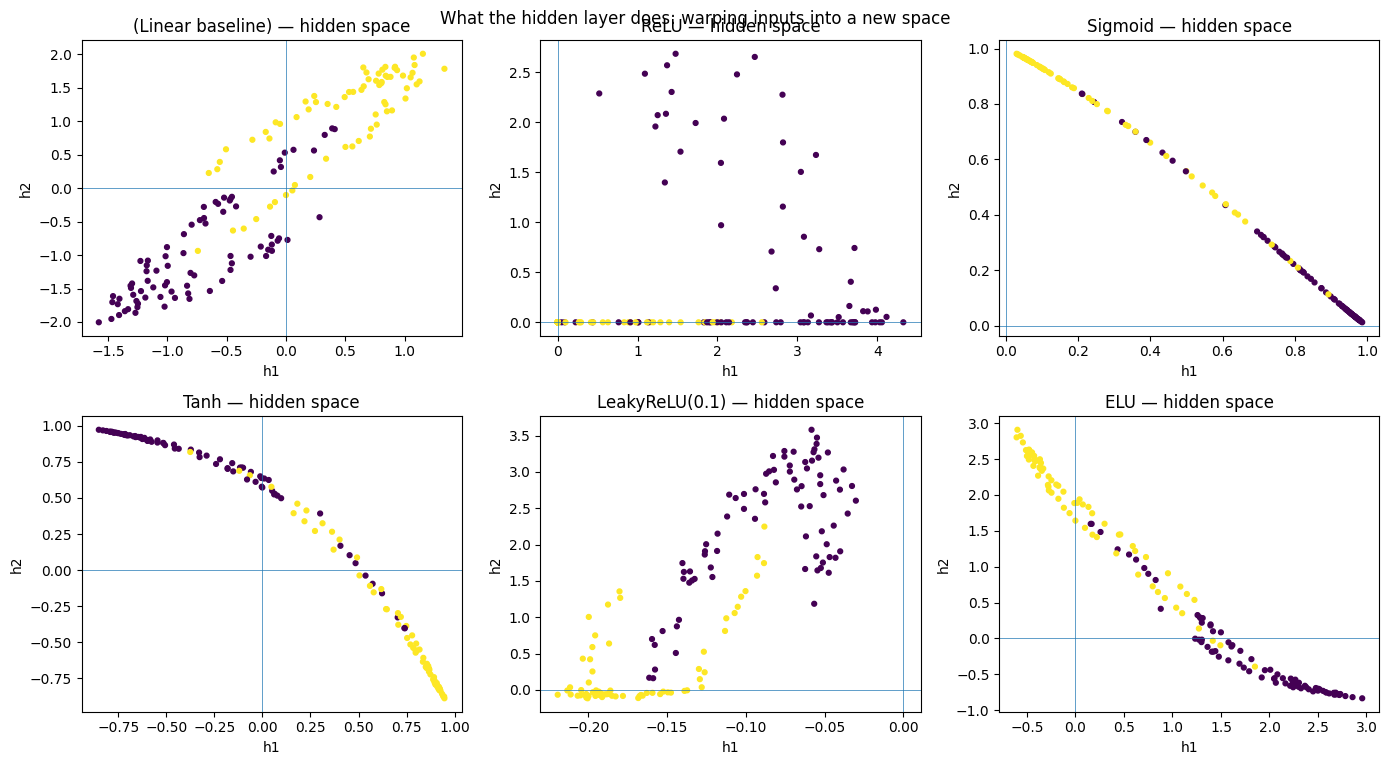

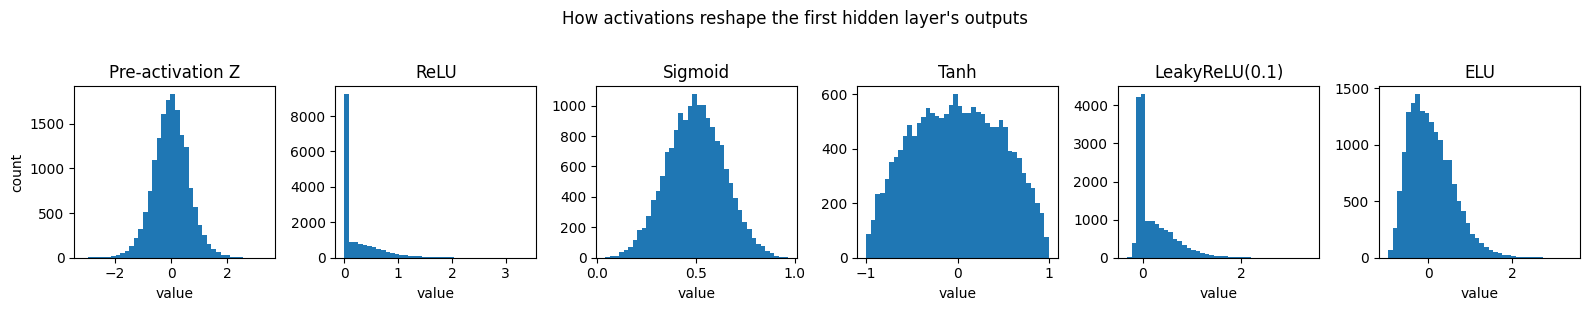


Takeaways:
1) Hidden layers learn new feature spaces. With 2 units we could SEE the warping.
2) Nonlinear activations let the model bend decision boundaries:
   • ReLU usually trains fast; simple piecewise linear boundaries.
   • Sigmoid/Tanh can fit well but may learn slower due to saturation (small gradients at extremes).
   • LeakyReLU avoids dead neurons by keeping a small negative slope.
   • ELU smooths negatives and pushes means toward ~0, which can help optimization.
3) Linear baseline struggles on non-linear data: stacking linear layers is still linear → poor boundary.
4) Loss/accuracy curves reveal training dynamics; compare how quickly each activation descends and where it plateaus.



In [13]:
# ==========================================================
# Demo Hidden Layers & Activations 
# Framework: Keras (TensorFlow backend). Plots with matplotlib.
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from keras.layers import Dense, Input
from keras.layers import LeakyReLU, ELU
from keras.optimizers import Adam
import tensorflow as tf

# ---------- Reproducibility ----------
np.random.seed(7)
tf.random.set_seed(7)

# ==========================================================
# Part A — Why activations? (Curves & gradients)
# ==========================================================

# Define the activation functions and their derivatives for plotting
def relu(x): return np.maximum(0, x)
def d_relu(x): return (x > 0).astype(np.float32)

def sigmoid(x): return 1 / (1 + np.exp(-x))
def d_sigmoid(x): s = sigmoid(x); return s * (1 - s)

def tanh(x): return np.tanh(x)
def d_tanh(x): t = tanh(x); return 1 - t**2

def leaky_relu(x, alpha=0.1): return np.where(x > 0, x, alpha * x)
def d_leaky_relu(x, alpha=0.1): return np.where(x > 0, 1.0, alpha)

def elu(x, alpha=1.0): 
    y = x.copy()
    y[x <= 0] = alpha * (np.exp(x[x <= 0]) - 1)
    return y
def d_elu(x, alpha=1.0):
    d = np.ones_like(x)
    m = x <= 0
    d[m] = alpha * np.exp(x[m])
    return d

acts = [
    ("ReLU", relu, d_relu),
    ("Sigmoid", sigmoid, d_sigmoid),
    ("Tanh", tanh, d_tanh),
    ("LeakyReLU(0.1)", lambda x: leaky_relu(x, 0.1), lambda x: d_leaky_relu(x, 0.1)),
    ("ELU", elu, d_elu)
]

# Plot activation curves and their derivatives
x = np.linspace(-5, 5, 400)
fig, axs = plt.subplots(2, 5, figsize=(16, 5), sharex=True)
for j, (name, f, df) in enumerate(acts):
    axs[0, j].plot(x, f(x))
    axs[0, j].set_title(name)
    axs[0, j].axhline(0, lw=0.5); axs[0, j].axvline(0, lw=0.5)
    axs[1, j].plot(x, df(x))
    axs[1, j].set_title(name + " derivative")
    axs[1, j].axhline(0, lw=0.5); axs[1, j].axvline(0, lw=0.5)
axs[0,0].set_ylabel("f(x)"); axs[1,0].set_ylabel("f'(x)"); axs[1,2].set_xlabel("x")
plt.suptitle("Activation functions and their gradients (why they help learning)", y=1.02)
plt.tight_layout(); plt.show()

print("""
Why use activations?
• Without a nonlinearity, stacking Dense layers collapses to a single linear map → can't model curved boundaries.
• Activations add nonlinearity, letting hidden layers bend/warp space to separate classes.
• Gradients (bottom row) show where learning is fast/slow:
  - Sigmoid/Tanh can saturate (near 0 or ±1), shrinking gradients.
  - ReLU is simple and fast but 'dies' for x<0 (gradient 0).
  - LeakyReLU keeps small gradient when x<0.
  - ELU smooths negatives and pushes mean activations toward 0, which can speed learning.
""")

# ==========================================================
# Part B — Build a non-linear classification toy dataset
# Two interleaving moons (no sklearn dependency)
# ==========================================================
def make_two_moons(n_samples=500, noise=0.1):
    n = n_samples // 2
    # First moon
    t1 = np.linspace(0, np.pi, n)
    x1 = np.c_[np.cos(t1), np.sin(t1)]
    # Second moon (shifted)
    t2 = np.linspace(0, np.pi, n)
    x2 = np.c_[1 - np.cos(t2), 1 - np.sin(t2) - 0.5]
    X = np.vstack([x1, x2]).astype(np.float32)
    y = np.hstack([np.zeros(n), np.ones(n)]).astype(np.float32)
    # Add gaussian noise
    X += noise * np.random.randn(*X.shape).astype(np.float32)
    return X, y

X, y = make_two_moons(600, noise=0.12)
print("Data shape:", X.shape, "Labels shape:", y.shape)

# Visualize dataset
plt.figure(figsize=(4.5,4))
plt.scatter(X[:,0], X[:,1], c=y, s=12)
plt.title("Two-Moons dataset (non-linear separable)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.tight_layout(); plt.show()

# Train/val split
idx = np.arange(len(X))
np.random.shuffle(idx)
train_idx = idx[:450]; val_idx = idx[450:]
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val     = X[val_idx], y[val_idx]

# ==========================================================
# Part C — A minimal MLP that exposes the hidden layer
# We'll set hidden_dim=2 so we can PLOT the hidden space directly!
# ==========================================================
hidden_dim = 2

def build_model(activation_name):
    inp = Input(shape=(2,), name="input_xy")
    # Hidden layer with 2 units so we can visualize its output space
    if activation_name == "ReLU":
        h = Dense(hidden_dim, activation="relu", name="hidden")(inp)
    elif activation_name == "Sigmoid":
        h = Dense(hidden_dim, activation="sigmoid", name="hidden")(inp)
    elif activation_name == "Tanh":
        h = Dense(hidden_dim, activation="tanh", name="hidden")(inp)
    elif activation_name == "LeakyReLU(0.1)":
        z = Dense(hidden_dim, name="hidden_pre")(inp)
        h = LeakyReLU(alpha=0.1, name="hidden")(z)
    elif activation_name == "ELU":
        z = Dense(hidden_dim, name="hidden_pre")(inp)
        h = ELU(name="hidden")(z)
    else:
        # Optional baseline: linear (no nonlinearity)
        h = Dense(hidden_dim, activation=None, name="hidden")(inp)
    out = Dense(1, activation="sigmoid", name="out")(h)
    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-2), loss="binary_crossentropy", metrics=["accuracy"])
    # A separate model to read the hidden activations
    hidden_reader = Model(inp, h)
    return model, hidden_reader

# Include an optional linear baseline first to contrast
activation_names = ["(Linear baseline)", "ReLU", "Sigmoid", "Tanh", "LeakyReLU(0.1)", "ELU"]

histories = {}
models = {}
hidden_readers = {}

for name in activation_names:
    model, reader = build_model("ReLU" if name=="(Linear baseline)" else name)
    if name=="(Linear baseline)":
        # Force the 'hidden' to be linear by replacing its activation with None
        # (works because build_model chose ReLU for the internal branch)
        for layer in model.layers:
            if layer.name == "hidden":
                # Rebuild a linear layer at same weights? Simpler: re-build purely linear:
                pass
        # Easiest: rebuild explicitly linear:
        model, reader = build_model("LINEAR_INTERNAL")
        # compile already done in build_model
    print(f"\nTraining with activation: {name}")
    h = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                  batch_size=64, epochs=200, verbose=0)
    histories[name] = h
    models[name] = model
    hidden_readers[name] = reader

# ==========================================================
# Part D — Plot decision boundaries + training curves
# ==========================================================
def plot_decision_boundary(ax, model, X, y, title=""):
    # grid
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xs = np.linspace(x_min, x_max, 200)
    ys = np.linspace(y_min, y_max, 200)
    XX, YY = np.meshgrid(xs, ys)
    grid = np.c_[XX.ravel(), YY.ravel()].astype(np.float32)
    Z = model.predict(grid, verbose=0).reshape(XX.shape)
    ax.contourf(XX, YY, Z, levels=[0,0.5,1], alpha=0.3)
    ax.scatter(X[:,0], X[:,1], c=y, s=12, edgecolors="none")
    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")

# (1) Decision boundaries
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
for ax, name in zip(axs.ravel(), activation_names):
    plot_decision_boundary(ax, models[name], X_val, y_val, title=name)
plt.suptitle("Effect of activation on learned decision boundary", y=0.95)
plt.tight_layout(); plt.show()

# (2) Loss curves
plt.figure(figsize=(10,5))
for name in activation_names:
    plt.plot(histories[name].history["loss"], label=name)
plt.title("Training loss vs epochs (lower is better)")
plt.xlabel("epoch"); plt.ylabel("binary crossentropy"); plt.legend()
plt.tight_layout(); plt.show()

# (3) Accuracy curves (validation)
plt.figure(figsize=(10,5))
for name in activation_names:
    plt.plot(histories[name].history["val_accuracy"], label=name)
plt.title("Validation accuracy vs epochs")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
plt.tight_layout(); plt.show()

# ==========================================================
# Part E — Visualize "input → hidden space" transformation
# Each hidden layer has 2 neurons, so we can scatter in 2D.
# ==========================================================
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
for ax, name in zip(axs.ravel(), activation_names):
    H = hidden_readers[name].predict(X_val, verbose=0)  # shape (N, 2)
    ax.scatter(H[:,0], H[:,1], c=y_val, s=12)
    ax.axhline(0, lw=0.5); ax.axvline(0, lw=0.5)
    ax.set_title(name + " — hidden space")
    ax.set_xlabel("h1"); ax.set_ylabel("h2")
plt.suptitle("What the hidden layer does: warping inputs into a new space", y=0.95)
plt.tight_layout(); plt.show()

# ==========================================================
# Part F — Show how activations shape pre-activations
# We'll push a random Gaussian through a single Dense layer, then apply each activation.
# ==========================================================
B, F, H = 1024, 4, 16
Xrand = np.random.randn(B, F).astype(np.float32)
dense = Dense(H, use_bias=True)
dense.build((None, F))
W, b = dense.get_weights()
Z = Xrand @ W + b  # pre-activation

fig, axs = plt.subplots(1, 6, figsize=(16,3))
axs[0].hist(Z.ravel(), bins=40); axs[0].set_title("Pre-activation Z")
axs[0].set_xlabel("value"); axs[0].set_ylabel("count")

# Apply each activation and plot the output distribution
transforms = [
    ("(Linear baseline)", lambda z: z),
    ("ReLU", relu),
    ("Sigmoid", sigmoid),
    ("Tanh", tanh),
    ("LeakyReLU(0.1)", lambda z: leaky_relu(z, 0.1)),
    ("ELU", elu)
]
for i, (name, f) in enumerate(transforms[1:], start=1):
    axs[i].hist(f(Z).ravel(), bins=40)
    axs[i].set_title(name)
    axs[i].set_xlabel("value")
plt.suptitle("How activations reshape the first hidden layer's outputs", y=1.02)
plt.tight_layout(); plt.show()

# ==========================================================
# Key talking points (print for your narration)
# ==========================================================
print("""
Takeaways:
1) Hidden layers learn new feature spaces. With 2 units we could SEE the warping.
2) Nonlinear activations let the model bend decision boundaries:
   • ReLU usually trains fast; simple piecewise linear boundaries.
   • Sigmoid/Tanh can fit well but may learn slower due to saturation (small gradients at extremes).
   • LeakyReLU avoids dead neurons by keeping a small negative slope.
   • ELU smooths negatives and pushes means toward ~0, which can help optimization.
3) Linear baseline struggles on non-linear data: stacking linear layers is still linear → poor boundary.
4) Loss/accuracy curves reveal training dynamics; compare how quickly each activation descends and where it plateaus.
""")
#“What representation does the hidden layer learn for the data?”

In [ ]:
#another example


--- Model Summary ---


Model: "mlp_hidden_demo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)


Batch shapes:
  Input X: (128, 10)
  Hidden1 activations: (128, 32)
  Hidden2 activations: (128, 16)


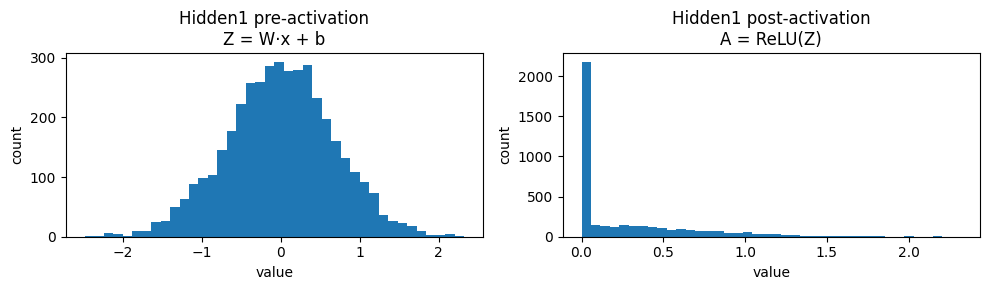

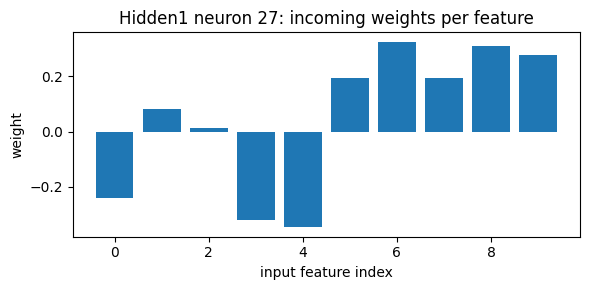


Teaching notes:
• In the Functional API, dataflow is explicit: Input → Hidden1 → Hidden2 → Output.
• Hidden1 (ReLU) shows how pre-activations get reshaped into non-linear outputs.
• Hidden2 (Tanh) stacks another transformation → richer features for the output layer.
• Histograms show the difference between raw Z and activated A.



In [16]:

# 1) Shows how data flows input → hidden layer → next layer
# 2) Visualizes pre-activation (Z = W·x + b) vs post-activation (A = activation(Z))
# 3) see why hidden layers + activations matter
# Framework: Keras (TensorFlow backend)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Dense

# ---------- Reproducibility ----------
np.random.seed(0)
tf.random.set_seed(0)

# ---------- Problem setup ----------
n_inputs = 10                       # number of input features/columns
batch_size = 128                    # toy batch to pass through the network
X = np.random.randn(batch_size, n_inputs).astype("float32")

# ---------- Build model (Functional API) ----------
inputs = Input(shape=(n_inputs,), name="input")
h1 = Dense(32, activation="relu", name="hidden1")(inputs)
h2 = Dense(16, activation="tanh", name="hidden2")(h1)
out = Dense(1, activation="sigmoid", name="output")(h2)

model = Model(inputs, out, name="mlp_hidden_demo")

print("\n--- Model Summary ---")
model.summary()

# ---------- Readers to inspect hidden activations ----------
hidden1_reader = Model(inputs, h1, name="reader_h1")
hidden2_reader = Model(inputs, h2, name="reader_h2")

# Forward pass: activations after each hidden layer
H1 = hidden1_reader.predict(X, verbose=0)   # shape: (batch, 32)
H2 = hidden2_reader.predict(X, verbose=0)   # shape: (batch, 16)

print("\nBatch shapes:")
print("  Input X:", X.shape)
print("  Hidden1 activations:", H1.shape)
print("  Hidden2 activations:", H2.shape)

# ---------- Visualize pre- vs post-activation for hidden1 ----------
# Pre-activation Z1 = X·W1 + b1
W1, b1 = model.get_layer("hidden1").get_weights()  # W1: (10,32)  b1: (32,)
Z1 = X @ W1 + b1                                   # -> (batch, 32)
A1 = H1                                            # post-activation already computed

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.hist(Z1.ravel(), bins=40)
plt.title("Hidden1 pre-activation\nZ = W·x + b")
plt.xlabel("value"); plt.ylabel("count")

plt.subplot(1,2,2)
plt.hist(A1.ravel(), bins=40)
plt.title("Hidden1 post-activation\nA = ReLU(Z)")
plt.xlabel("value"); plt.ylabel("count")
plt.tight_layout(); plt.show()

# ---------- (Optional) Peek at a single neuron's weights ----------
neuron_idx = int(np.argmax(np.linalg.norm(W1, axis=0)))  # strongest incoming weights
plt.figure(figsize=(6,3))
plt.bar(np.arange(n_inputs), W1[:, neuron_idx])
plt.title(f"Hidden1 neuron {neuron_idx}: incoming weights per feature")
plt.xlabel("input feature index"); plt.ylabel("weight")
plt.tight_layout(); plt.show()

print("""
Teaching notes:
• In the Functional API, dataflow is explicit: Input → Hidden1 → Hidden2 → Output.
• Hidden1 (ReLU) shows how pre-activations get reshaped into non-linear outputs.
• Hidden2 (Tanh) stacks another transformation → richer features for the output layer.
• Histograms show the difference between raw Z and activated A.
""")


In [18]:
######################################################################################################################################################################################################################################

In [ ]:
################################# Demo 2.8 Python Demo: Build Hidden Layer###################################################################################################################

In [ ]:
#how the final layer is defined differently depending on the type of task:

#Regression → outputs continuous values (e.g., house price)

#Binary classification → outputs probability between 0–1

#Multi-class classification → outputs probability distribution across classes


Regression output shape: (128, 1)
First 5 regression outputs: [-0.02265993 -0.68915766  1.033272    1.5663671   0.37883973]


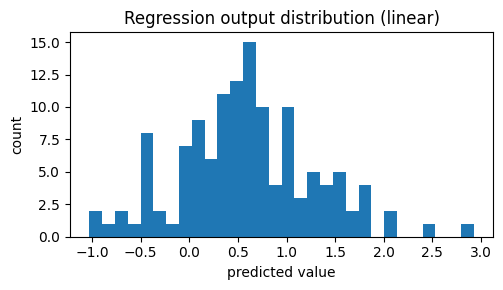


Binary classification output shape: (128, 1)
First 5 binary outputs (probabilities): [0.6556986  0.51374465 0.43874508 0.19123207 0.62414604]


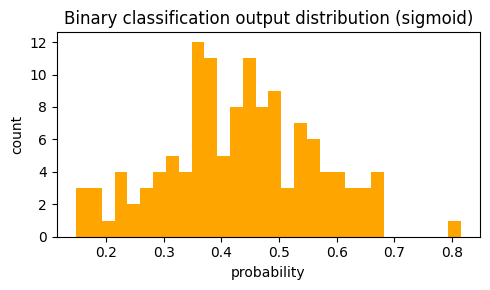


Multi-class classification output shape: (128, 3)
First row (class probabilities): [0.42810628 0.24755135 0.32434237]


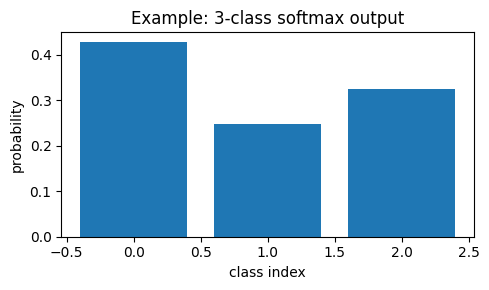


Final notes:
• Regression → last Dense has 1 neuron, activation=None (linear output).
  Example: predict house price, temperature, stock value.

• Binary classification → last Dense has 1 neuron, activation='sigmoid'.
  Output is a probability between 0 and 1.
  Example: spam vs not-spam, big vs small...etc

• Multi-class classification → last Dense has N neurons, activation='softmax'.
  Output is a vector of probabilities summing to 1.
  Example: classify image as cat/dog/horse.

The choice of OUTPUT layer defines what the network learns and how we interpret predictions.



In [20]:
################################# Output Layer #################################
# Goal: Show how the output layer changes for regression vs classification
# Framework: Keras (TensorFlow backend)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Dense, Softmax

# ---------- Reproducibility ----------
np.random.seed(1)
tf.random.set_seed(1)

# ---------- Synthetic input (10 features) ----------
n_inputs = 10
batch_size = 128
X = np.random.randn(batch_size, n_inputs).astype("float32")







# ---------- 1) Regression model (predict continuous value) ----------
inp = Input(shape=(n_inputs,), name="input_reg")
h = Dense(16, activation="relu")(inp)
out_reg = Dense(1, activation=None, name="output_reg")(h)  # no activation → linear output # In Keras, the Dense layer applies a linear transformation by default
model_reg = Model(inp, out_reg, name="regression_model")
y_reg = model_reg.predict(X, verbose=0)

print("\nRegression output shape:", y_reg.shape)
print("First 5 regression outputs:", y_reg[:5].ravel())

plt.figure(figsize=(5,3))
plt.hist(y_reg.ravel(), bins=30)
plt.title("Regression output distribution (linear)")
plt.xlabel("predicted value"); plt.ylabel("count")
plt.tight_layout(); plt.show()












# ---------- 2) Binary classification model ----------
inp = Input(shape=(n_inputs,), name="input_bin")
h = Dense(16, activation="relu")(inp)
out_bin = Dense(1, activation="sigmoid", name="output_bin")(h)  # sigmoid → [0,1] probability
model_bin = Model(inp, out_bin, name="binary_model")
y_bin = model_bin.predict(X, verbose=0)

print("\nBinary classification output shape:", y_bin.shape)
print("First 5 binary outputs (probabilities):", y_bin[:5].ravel())

plt.figure(figsize=(5,3))
plt.hist(y_bin.ravel(), bins=30, color="orange")
plt.title("Binary classification output distribution (sigmoid)")
plt.xlabel("probability"); plt.ylabel("count")
plt.tight_layout(); plt.show()
















# ---------- 3) Multi-class classification model ----------
n_classes = 3
inp = Input(shape=(n_inputs,), name="input_multi")
h = Dense(16, activation="relu")(inp)
out_multi = Dense(n_classes, activation="softmax", name="output_multi")(h)  # softmax → probabilities across classes
model_multi = Model(inp, out_multi, name="multiclass_model")
y_multi = model_multi.predict(X, verbose=0)

print("\nMulti-class classification output shape:", y_multi.shape)
print("First row (class probabilities):", y_multi[0])

plt.figure(figsize=(5,3))
plt.bar(range(n_classes), y_multi[0])
plt.title("Example: 3-class softmax output")
plt.xlabel("class index"); plt.ylabel("probability")
plt.tight_layout(); plt.show()
















# ---------- final notes ----------
print("""
Final notes:
• Regression → last Dense has 1 neuron, activation=None (linear output).
  Example: predict house price, temperature, stock value.

• Binary classification → last Dense has 1 neuron, activation='sigmoid'.
  Output is a probability between 0 and 1.
  Example: spam vs not-spam, big vs small...etc

• Multi-class classification → last Dense has N neurons, activation='softmax'.
  Output is a vector of probabilities summing to 1.
  Example: classify image as cat/dog/horse.

The choice of OUTPUT layer defines what the network learns and how we interpret predictions.
""")


In [ ]:
#“Next week, we’ll dive into how a neural network actually learns: exploring loss functions, how to choose the right number of layers and neurons,
#and how to decide which activation functions to use